# VAE with Euclidean Latent Space

In [1]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import torch
import numpy as np
import torch.optim as optim

import code.manifold_vae.lib.dataloaders as dataloaders
import code.manifold_vae.lib.models as models
import code.manifold_vae.lib.trainer as trainer
import code.manifold_vae.lib.utils as utils


ImportError: cannot import name 'scalar_search_wolfe2' from 'scipy.optimize.linesearch' (/home/timtom/miniconda3/envs/mvae-env/lib/python3.10/site-packages/scipy/optimize/linesearch.py)


### Set up and initialize data loader

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [5]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)

### Model

In [6]:
data_dim = 784
latent_dim = 20
sftbeta = 1
device = "cpu"
encoder_width = 2
encoder_depth = 128
decoder_width = 2
decoder_depth = 128

model_config = { 'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device, 'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width, 'decoder_depth': decoder_depth}

hyperbolic_model = models.HyperbolicVAE(model_config)

### Optimizer

In [7]:
learning_rate = 0.001

hyperbolic_optimizer = optim.Adam(hyperbolic_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [8]:
num_epochs = 2
log_interval = 100
device = "cpu"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device}

hyperbolic_train_losses, hyperbolic_test_losses = trainer.MVAETrainer(hyperbolic_model, dataloader, hyperbolic_optimizer, trainer_config).train()


Trainer successfully initialized.
Training thegaussianVAE model.
Starting epoch 1/10
Epoch [1/10], Step [100/938], Loss: 161.9806
Epoch [1/10], Step [200/938], Loss: 79.4237
Epoch [1/10], Step [300/938], Loss: 39.9064
Epoch [1/10], Step [400/938], Loss: 20.3148
Epoch [1/10], Step [500/938], Loss: 10.5346
Epoch [1/10], Step [600/938], Loss: 5.6458
Epoch [1/10], Step [700/938], Loss: 3.1685
Epoch [1/10], Step [800/938], Loss: 1.8845
Epoch [1/10], Step [900/938], Loss: 1.1700
Epoch 1/10, Train Loss: 0.7913, Test Loss: 0.0153
--------------------------------------------------
Starting epoch 2/10
Epoch [2/10], Step [100/938], Loss: 0.6478
Epoch [2/10], Step [200/938], Loss: 0.4265
Epoch [2/10], Step [300/938], Loss: 0.2894
Epoch [2/10], Step [400/938], Loss: 0.2038
Epoch [2/10], Step [500/938], Loss: 0.1595
Epoch [2/10], Step [600/938], Loss: 0.1281
Epoch [2/10], Step [700/938], Loss: 0.1144
Epoch [2/10], Step [800/938], Loss: 0.1011
Epoch [2/10], Step [900/938], Loss: 0.0980
Epoch 2/10, Tr

### Visualization 

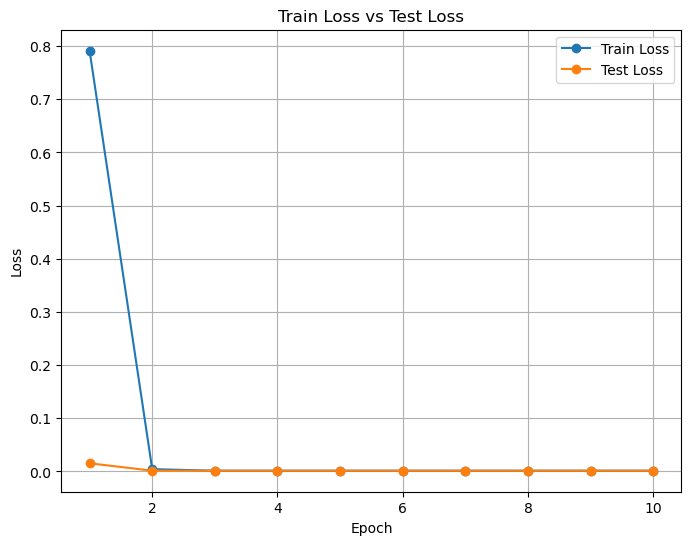

In [9]:
utils.plot_losses(hyperbolic_train_losses, hyperbolic_test_losses, num_epochs)

### Save trained models

In [11]:
#lib.models.utils.save_load_models.save_model(euclidean_model, model_config)
#code.manifold_vae.lib.models.utils.save_load_models.save_model(toroidal_model, model_config)

Model saved as gaussian_1738946158.pth
Model saved as gaussian_1738946158.json
Model saved as toroidal_1738946158.pth
Model saved as toroidal_1738946158.json


### Load pretrained models

In [12]:
#model = manifold_vae.utils.load_model("gaussian_1738932113")

In [13]:
#model